In [1]:
import pandas as pd

import matplotlib.pyplot as plt

In [4]:
import undetected_chromedriver as uc
from bs4 import BeautifulSoup
driver = uc.Chrome(version_main=148)

In [7]:
url = 'https://fbref.com/en/comps/Big5/2023-2024/2023-2024-Big-5-European-Leagues-Stats'

In [8]:
driver.get(url)

In [9]:
df = pd.read_html(driver.page_source, attrs= {'id' : "big5_table"})[0]

df.head()

C:\Users\pawan\AppData\Local\Temp\ipykernel_13920\2290498928.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(driver.page_source, attrs= {'id' : "big5_table"})[0]


,Rk,Squad,Country,LgRk,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Attendance,Top Team Scorer,Goalkeeper
0,1,Leverkusen,de GER,1,34,28,6,0,89,24,+65,90,2.65,29994,Victor Boniface - 14,Lukáš Hrádecký
1,2,Real Madrid,es ESP,1,38,29,8,1,87,26,+61,95,2.50,72061,Jude Bellingham - 19,Andriy Lunin
2,3,Inter,it ITA,1,38,29,7,2,89,22,+67,94,2.47,72838,Lautaro Martínez - 24,Yann Sommer
3,4,Manchester City,eng ENG,1,38,28,7,3,96,34,+62,91,2.39,53012,Erling Haaland - 27,Ederson
4,5,Arsenal,eng ENG,2,38,28,5,5,91,29,+62,89,2.34,60236,Bukayo Saka - 16,David Raya


DTypePromotionError: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

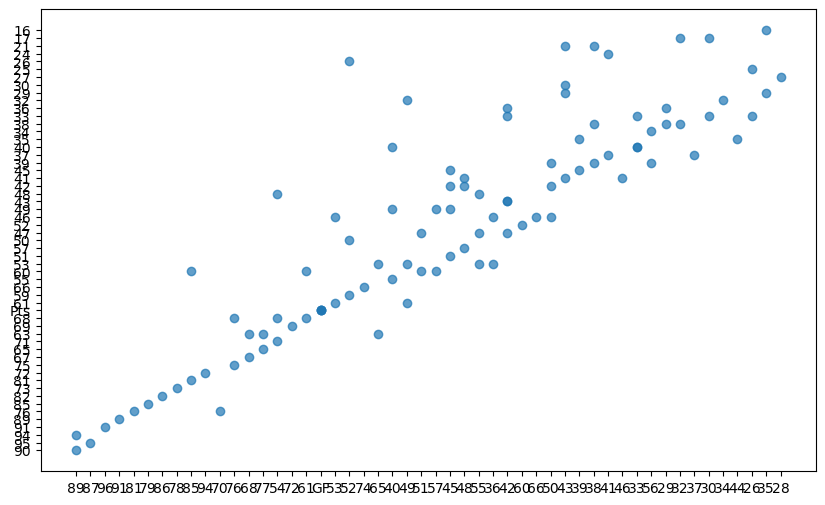

In [14]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(
    x=df['GF'],
    y=df['Pts'],
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'},
    ax=ax
)

ax.set_title("Goals vs Points")
plt.show()

In [16]:
df['GF'] = pd.to_numeric(df['GF'], errors='coerce')
df['Pts'] = pd.to_numeric(df['Pts'], errors='coerce')